# Number of pairs of cells on one channel

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean/dataframes' ### here the resulting dataframes will be saved
MONKEY_LIST = ['L','N','F'] #,'A']
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']
AREAS = params_analysis['areas']

AREA = 'V12'

In [4]:
CELL_PAIRS_MAPPING = {'maroon_blue': 'NarrBI+Wide',
                      'orange_maroon': 'MedBI+NarrBI',
                      'orange_blue': 'MedBI+Wide',
                      'red_green': 'NarrTRI+Pos',
                      'green_green': 'Pos+Pos',
                      'yellow_yellow': 'MedTRI+MedTRI',
                      'red_red': 'NarrTRI+NarrTRI',
                      'blue_blue': 'Wide+Wide',
                      'orange_orange': 'MedBI+MedBI',
                      'maroon_maroon': 'NarrBI+NarrBI',
                      'blue_green': 'Wide+Pos',
                      'maroon_green': 'NarrBI+Pos',
                      'maroon_red': 'NarrBI+NarrTRI',
                      'orange_green': 'MedBI+Pos',
                      'orange_red': 'MedBI+NarrTRI',
                      'orange_yellow': 'MedBI+MedTRI',
                      'red_blue': 'NarrTRI+Wide',
                      'yellow_blue': 'MedTRI+Wide',
                      'yellow_green': 'MedTRI+Pos',
                      'yellow_red': 'MedTRI+NarrTRI',
                      'yellow_maroon': 'MedTRI+NarrBI'
                     }

## Functions

In [5]:
def count_num_cells_ch(ch_arr, cl_arr):
    """
    Auxiliary.
    Number of cells and their classes.
    """
    num_cells_dict = {}
    classes_cells_dict = {}
    for ch in range(64):
        cell_idx_ch = np.where(ch_arr==ch)[0]
        num_cells_ch = len(cell_idx_ch)
        num_cells_dict[ch] = num_cells_ch
        if num_cells_ch>0:
            classes_cells_dict[ch] = cl_arr[cell_idx_ch]
        else:
            classes_cells_dict[ch] = []
    
    return num_cells_dict, classes_cells_dict

## Preprocessing the data - counting pairs

In [6]:
data_dicts = []
for monkey in MONKEY_LIST:
    print(monkey)
    for date in DATES[monkey]['RS']:
        print(date)
        file_path = f'/CSNG/studekat/ripple_paper_clean/dataframes/shuffle_cell_pairs_bin_05/{monkey}_{date}_N_1000_width_20.pkl'
        with open(file_path, "rb") as f:
            loaded_data = pickle.load(f)
        data_dicts.append(loaded_data)

data_merged = list_merge(data_dicts)

L
20170725
20170809
20170810
N
20240719_B1
20240719_B2
F
20240122_B1
20241216_B1


In [7]:
df_merged = pd.DataFrame(data_merged)

In [8]:
df_merged.head(1)

,monkey,date,channel,pair_idx,class_names,size_whole_group,max_lag,min_lag,val_max_lag,val_min_lag,data_spike_dist,max_density_shuffle,max_lag_density_shuffle,min_density_shuffle,min_lag_density_shuffle
0,L,20170725,55,"[0, 1]","[DOWN_medium_shallow, DOWN_medium_shallow]",2,-3.0,-20.0,0.052865,0.010103,"[29, 8, 8, 1, 0, 19, 6, 15, 11, 9, 7, 544, 31,...","[0.03904057157438122, 0.03624093976505874, 0.0...","[[0.03495789742281194], [0.031492126968257934]...","[0.015437611635621332, 0.013996500874781305, 0...","[[0.016968614442459812], [0.016745813546613347..."


In [9]:
counts_df = (
    df_merged['class_names']
    .apply(lambda x: tuple(sorted(x)))
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'pair', 'pairs': 'count'})
)

In [10]:
counts_df.head(1)

,class_names,count
0,"(DOWN_medium_shallow, DOWN_narrow_shallow)",49


## Visualisation

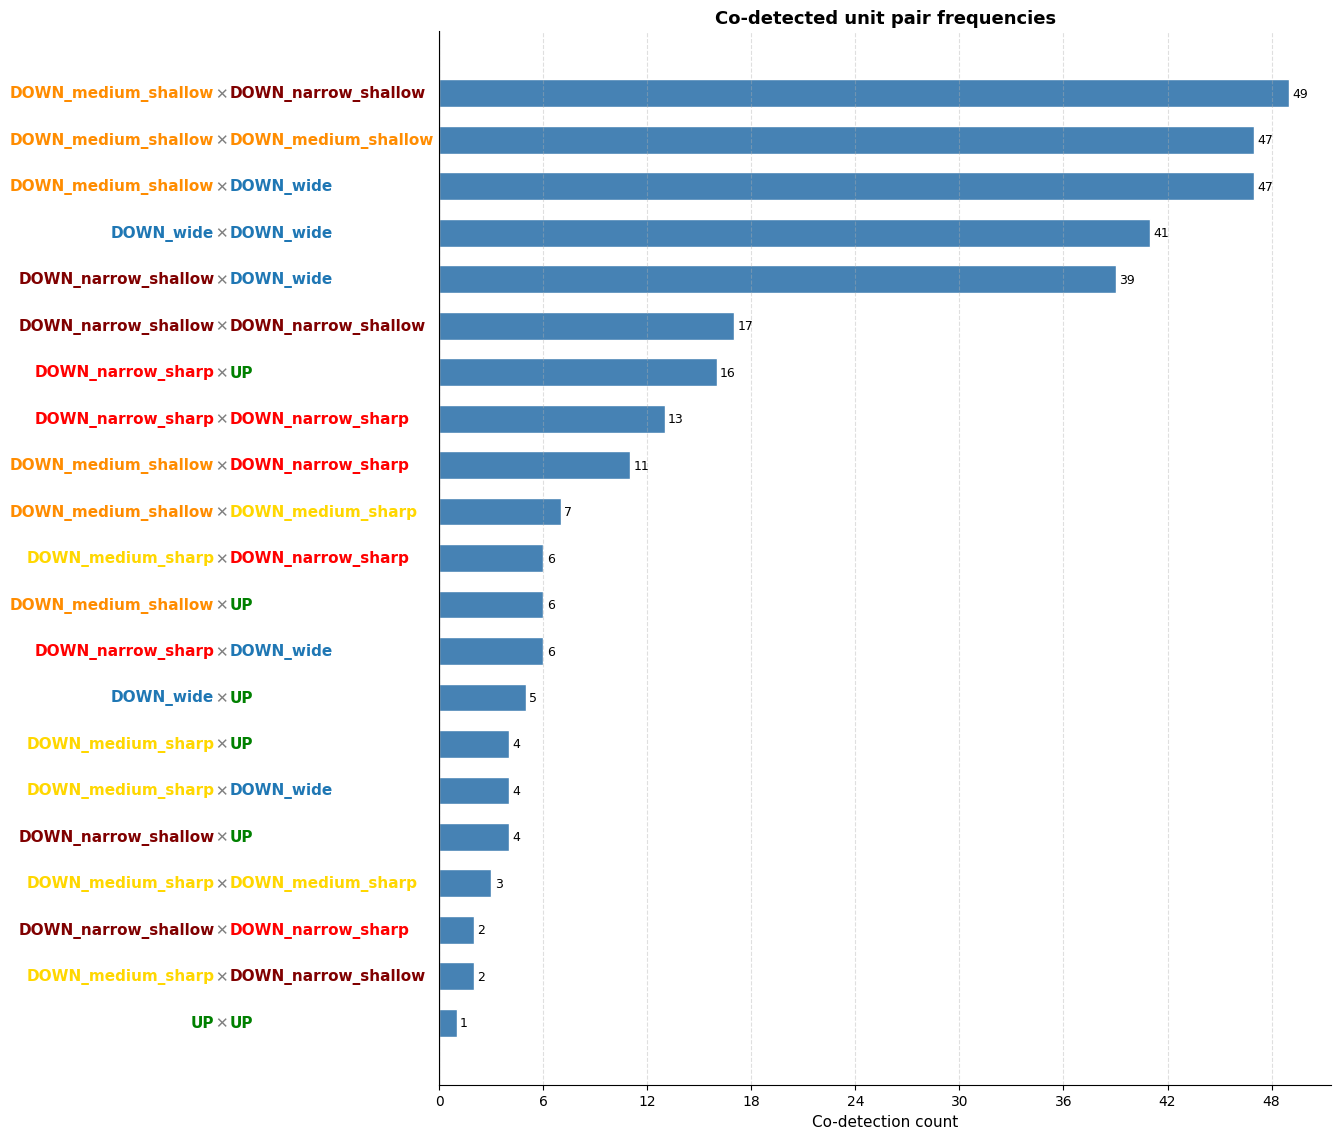

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(14, len(counts_df) * 0.5 + 1))

bars = ax.barh(
    range(len(counts_df)),
    counts_df['count'],
    color='steelblue',
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars, counts_df['count']):
    ax.text(
        bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', ha='left', fontsize=9
    )

separator = ' ✕ '
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

# Helper: measure text width in data coordinates
def text_width(s, fontsize, fontweight='normal'):
    t = ax.text(0, 0, s, ha='left', va='center', fontsize=fontsize,
                fontweight=fontweight, alpha=0)
    fig.canvas.draw()
    bbox = t.get_window_extent(renderer=renderer)
    w = ax.transData.inverted().transform(bbox)
    t.remove()
    return w[1][0] - w[0][0]

sep_w   = text_width(separator, 9)
max_n2w = max(text_width(pair[1], 12, 'bold') for pair in counts_df['class_names'])

# Fix separator center so name2 always ends at x=0
offset = 1.5  # adjust this value to taste
sep_cx = -max_n2w - sep_w / 2 - offset

for i, pair in enumerate(counts_df['class_names']):
    name1, name2 = pair[0], pair[1]

    # Separator at fixed centre
    ax.text(sep_cx, i, separator, ha='center', va='center', fontsize=11,
            color='gray', transform=ax.transData)

    # name2 left-aligned from separator right edge
    ax.text(sep_cx + sep_w / 2, i, name2, ha='left', va='center', fontsize=11,
            color=CLASS_COLORS.get(name2, 'black'), fontweight='bold',
            transform=ax.transData)

    # name1 right-aligned from separator left edge
    ax.text(sep_cx - sep_w / 2, i, name1, ha='right', va='center', fontsize=11,
            color=CLASS_COLORS.get(name1, 'black'), fontweight='bold',
            transform=ax.transData)

ax.set_yticks([])
ax.set_xlabel('Co-detection count', fontsize=11)
ax.set_title('Co-detected unit pair frequencies', fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()